# Notebook 09 — Determinism & Anomaly Detection

**Family**: Red-herring hunting

**Lenses**:
- Hardcoded FV detection (mode prevalence ≥ 90% of ticks)
- Category sum constraint detection (near-constant 5-product sums)
- Periodic step pattern detection (zero-return clustering, grid discreteness)
- Outlier ticks > 5σ (per-day basis)
- Gap detection (missing timestamps)
- Near-identical timeseries (corr > 0.99 between products)
- FFT periodicity vs shuffled-return null distribution
- Random-product control (synthetic GBM baseline)

**Data**: `data/round_5/prices/prices_round_5_day_{2,3,4}.csv` (read-only)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load all three days
BASE = '/Users/bensinek/Documents/Coding/Prosperity4/data/round_5/prices'
dfs = []
for d in [2, 3, 4]:
    df = pd.read_csv(f'{BASE}/prices_round_5_day_{d}.csv', sep=';')
    df['day'] = d
    dfs.append(df)
all_df = pd.concat(dfs, ignore_index=True)

products = sorted(all_df['product'].unique())
categories = {
    'GALAXY': ['GALAXY_SOUNDS_DARK_MATTER','GALAXY_SOUNDS_BLACK_HOLES','GALAXY_SOUNDS_PLANETARY_RINGS','GALAXY_SOUNDS_SOLAR_WINDS','GALAXY_SOUNDS_SOLAR_FLAMES'],
    'SLEEP': ['SLEEP_POD_SUEDE','SLEEP_POD_LAMB_WOOL','SLEEP_POD_POLYESTER','SLEEP_POD_NYLON','SLEEP_POD_COTTON'],
    'MICROCHIP': ['MICROCHIP_CIRCLE','MICROCHIP_OVAL','MICROCHIP_SQUARE','MICROCHIP_RECTANGLE','MICROCHIP_TRIANGLE'],
    'PEBBLES': ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL'],
    'ROBOT': ['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_DISHES','ROBOT_LAUNDRY','ROBOT_IRONING'],
    'UV_VISOR': ['UV_VISOR_YELLOW','UV_VISOR_AMBER','UV_VISOR_ORANGE','UV_VISOR_RED','UV_VISOR_MAGENTA'],
    'TRANSLATOR': ['TRANSLATOR_SPACE_GRAY','TRANSLATOR_ASTRO_BLACK','TRANSLATOR_ECLIPSE_CHARCOAL','TRANSLATOR_GRAPHITE_MIST','TRANSLATOR_VOID_BLUE'],
    'PANEL': ['PANEL_1X2','PANEL_2X2','PANEL_1X4','PANEL_2X4','PANEL_4X4'],
    'OXYGEN_SHAKE': ['OXYGEN_SHAKE_MORNING_BREATH','OXYGEN_SHAKE_EVENING_BREATH','OXYGEN_SHAKE_MINT','OXYGEN_SHAKE_CHOCOLATE','OXYGEN_SHAKE_GARLIC'],
    'SNACKPACK': ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY'],
}

pivot_all = all_df.pivot_table(index=['day','timestamp'], columns='product', values='mid_price')

print(f'Loaded {len(all_df):,} rows across 3 days, {len(products)} products')
print(f'Ticks per product per day: {all_df.groupby(["day","product"])["timestamp"].count().iloc[0]}')

Loaded 1,500,000 rows across 3 days, 50 products
Ticks per product per day: 10000


## 1. Hardcoded FV Detection (mode prevalence ≥ 90%)

Scanning all 50 products for a single mid_price value dominating ≥ 90% of ticks.

In [2]:
print('=== Mode prevalence scan (all 50 products) ===')
mode_results = []
for prod in products:
    sub = all_df[all_df['product'] == prod]['mid_price']
    mode_val = sub.mode()[0]
    mode_pct = (sub == mode_val).mean() * 100
    n_distinct = sub.nunique()
    mode_results.append({'product': prod, 'mode_val': mode_val, 'mode_pct': mode_pct, 'n_distinct': n_distinct})

mode_df = pd.DataFrame(mode_results).sort_values('mode_pct', ascending=False)
print(mode_df.head(10).to_string(index=False))
print()
print(f'Products with mode_pct >= 90%: {(mode_df.mode_pct >= 90).sum()}')
print(f'Products with mode_pct >= 5%:  {(mode_df.mode_pct >= 5).sum()}')
print(f'Products with mode_pct >= 1%:  {(mode_df.mode_pct >= 1).sum()}')

=== Mode prevalence scan (all 50 products) ===


                    product  mode_val  mode_pct  n_distinct
               ROBOT_DISHES   10600.0  5.380000        3048
OXYGEN_SHAKE_EVENING_BREATH   10100.0  2.273333         453
              ROBOT_IRONING   10000.0  1.770000         631
     OXYGEN_SHAKE_CHOCOLATE    9250.0  0.646667        3512
          SNACKPACK_VANILLA    9975.5  0.283333        1673
        SNACKPACK_CHOCOLATE   10005.5  0.273333        1900
        SNACKPACK_RASPBERRY    9922.5  0.270000        1634
        SNACKPACK_PISTACHIO    9378.0  0.263333        1928
   TRANSLATOR_GRAPHITE_MIST    9962.5  0.206667        3937
  GALAXY_SOUNDS_DARK_MATTER   10169.5  0.190000        2907

Products with mode_pct >= 90%: 0
Products with mode_pct >= 5%:  1
Products with mode_pct >= 1%:  3


## 2. Category Sum Constraint Detection

For each of the 10 categories, compute the 5-product sum's coefficient of variation (CV%). A near-zero CV implies a hard sum constraint (basket FV).

In [3]:
print('=== Category 5-product sum analysis ===')
sum_results = []
for cat, prods in categories.items():
    total = pivot_all[prods].sum(axis=1)
    sum_results.append({
        'category': cat,
        'sum_mean': total.mean(),
        'sum_std': total.std(),
        'cv_pct': total.std() / total.mean() * 100,
        'n_unique': total.nunique(),
        'pct_within_0.5': (np.abs(total - total.mean()) <= 0.5).mean() * 100,
    })

sum_df = pd.DataFrame(sum_results).sort_values('cv_pct')
print(sum_df.to_string(index=False))

=== Category 5-product sum analysis ===
    category     sum_mean     sum_std   cv_pct  n_unique  pct_within_0.5
     PEBBLES 49999.939583    2.798488 0.005597        18       64.773333
   SNACKPACK 50220.938600  189.579405 0.377491      1755        0.213333
    UV_VISOR 51470.749700  742.334701 1.442246      6382        0.060000
  TRANSLATOR 49574.081950  816.706930 1.647447      6871        0.050000
       ROBOT 48809.635883  807.827900 1.655058      6200        0.050000
       PANEL 49041.000317  850.365162 1.733988      7060        0.050000
OXYGEN_SHAKE 50593.261333 1083.101799 2.140802      7218        0.013333
   MICROCHIP 49408.062733 1501.929900 3.039848     10337        0.020000
      GALAXY 53990.322750 1645.037970 3.046913     10149        0.040000
       SLEEP 55103.509633 2855.141116 5.181414     13653        0.003333


In [4]:
# Deep dive: PEBBLES sum
prods_pebbles = ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL']
pebbles_sum = pivot_all[prods_pebbles].sum(axis=1)

print('PEBBLES 5-product sum distribution:')
print(f'  Mean: {pebbles_sum.mean():.4f}')
print(f'  Std:  {pebbles_sum.std():.4f}')
print(f'  CV:   {pebbles_sum.std()/pebbles_sum.mean()*100:.6f}%')
print(f'  Sum == 50000 exactly: {(pebbles_sum==50000).sum()}/{len(pebbles_sum)} = {(pebbles_sum==50000).mean()*100:.1f}%')
print(f'  |sum - 50000| <= 0.5: {(np.abs(pebbles_sum-50000)<=0.5).sum()}/{len(pebbles_sum)} = {(np.abs(pebbles_sum-50000)<=0.5).mean()*100:.1f}%')
print(f'  |sum - 50000| <= 1.5: {(np.abs(pebbles_sum-50000)<=1.5).sum()}/{len(pebbles_sum)} = {(np.abs(pebbles_sum-50000)<=1.5).mean()*100:.1f}%')
print(f'  Unique sum values: {pebbles_sum.nunique()}')
print()
print('Top 10 sum values:')
print(pebbles_sum.value_counts().head(10))

# Per-day
print()
print('Per-day PEBBLES sum:')
for d in [2, 3, 4]:
    sub = all_df[all_df['day']==d].pivot_table(index='timestamp', columns='product', values='mid_price')
    s = sub[prods_pebbles].sum(axis=1)
    print(f'  Day {d}: mean={s.mean():.4f}, std={s.std():.4f}, unique={s.nunique()}')

PEBBLES 5-product sum distribution:
  Mean: 49999.9396
  Std:  2.7985
  CV:   0.005597%
  Sum == 50000 exactly: 12188/30000 = 40.6%
  |sum - 50000| <= 0.5: 26681/30000 = 88.9%
  |sum - 50000| <= 1.5: 29147/30000 = 97.2%
  Unique sum values: 18

Top 10 sum values:
50000.0    12188
50000.5     7249
49999.5     7244
49999.0     1215
50001.0     1147
49982.5      194
50015.0      179
49983.0      115
49982.0      107
50015.5      104
Name: count, dtype: int64

Per-day PEBBLES sum:
  Day 2: mean=49999.9080, std=2.8157, unique=17


  Day 3: mean=49999.9700, std=2.7578, unique=18


  Day 4: mean=49999.9408, std=2.8214, unique=17


In [5]:
from statsmodels.tsa.stattools import adfuller

# ADF stationarity test on PEBBLES sum (confirms mean reversion / pinning)
adf_pebbles = adfuller(pebbles_sum.values)
print(f'ADF test on PEBBLES 5-sum (all days): stat={adf_pebbles[0]:.4f}, p={adf_pebbles[1]:.10f}')
print('(p << 0.05 confirms sum is mean-reverting, consistent with hard constraint)')

# Compare to ROBOT (not constrained)
prods_robot = ['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_DISHES','ROBOT_LAUNDRY','ROBOT_IRONING']
robot_sum = pivot_all[prods_robot].sum(axis=1)
adf_robot = adfuller(robot_sum.values)
print(f'ADF test on ROBOT 5-sum (all days):   stat={adf_robot[0]:.4f}, p={adf_robot[1]:.6f}')

ADF test on PEBBLES 5-sum (all days): stat=-122.6908, p=0.0000000000
(p << 0.05 confirms sum is mean-reverting, consistent with hard constraint)


ADF test on ROBOT 5-sum (all days):   stat=-2.5195, p=0.110813


In [6]:
# SNACKPACK: second lowest CV at 0.38%
prods_snack = ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY']
snack_sum = pivot_all[prods_snack].sum(axis=1)

# CHOC + VAN pair
choc_van = pivot_all['SNACKPACK_CHOCOLATE'] + pivot_all['SNACKPACK_VANILLA']
print('SNACKPACK CHOCOLATE + VANILLA pair:')
print(f'  Corr(CHOC, VAN): {pivot_all["SNACKPACK_CHOCOLATE"].corr(pivot_all["SNACKPACK_VANILLA"]):.4f}')
print(f'  Sum mean={choc_van.mean():.2f}, std={choc_van.std():.2f}, CV={choc_van.std()/choc_van.mean()*100:.3f}%')
print(f'  Unique sum values: {choc_van.nunique()}')
adf_cv = adfuller(choc_van.values)
print(f'  ADF on sum: stat={adf_cv[0]:.4f}, p={adf_cv[1]:.6f} (p>0.05 = NOT stationary -- sum drifts)')

print()
print('SNACKPACK CHOC+VAN per-day means (confirming drift across days):')
for d in [2, 3, 4]:
    sub = all_df[all_df['day']==d].pivot_table(index='timestamp', columns='product', values='mid_price')
    s = sub['SNACKPACK_CHOCOLATE'] + sub['SNACKPACK_VANILLA']
    print(f'  Day {d}: mean={s.mean():.1f}, std={s.std():.2f}')

SNACKPACK CHOCOLATE + VANILLA pair:
  Corr(CHOC, VAN): -0.9259
  Sum mean=19940.67, std=76.20, CV=0.382%
  Unique sum values: 667


  ADF on sum: stat=-1.7613, p=0.399841 (p>0.05 = NOT stationary -- sum drifts)

SNACKPACK CHOC+VAN per-day means (confirming drift across days):
  Day 2: mean=20025.0, std=42.48
  Day 3: mean=19926.9, std=31.60


  Day 4: mean=19870.1, std=48.22


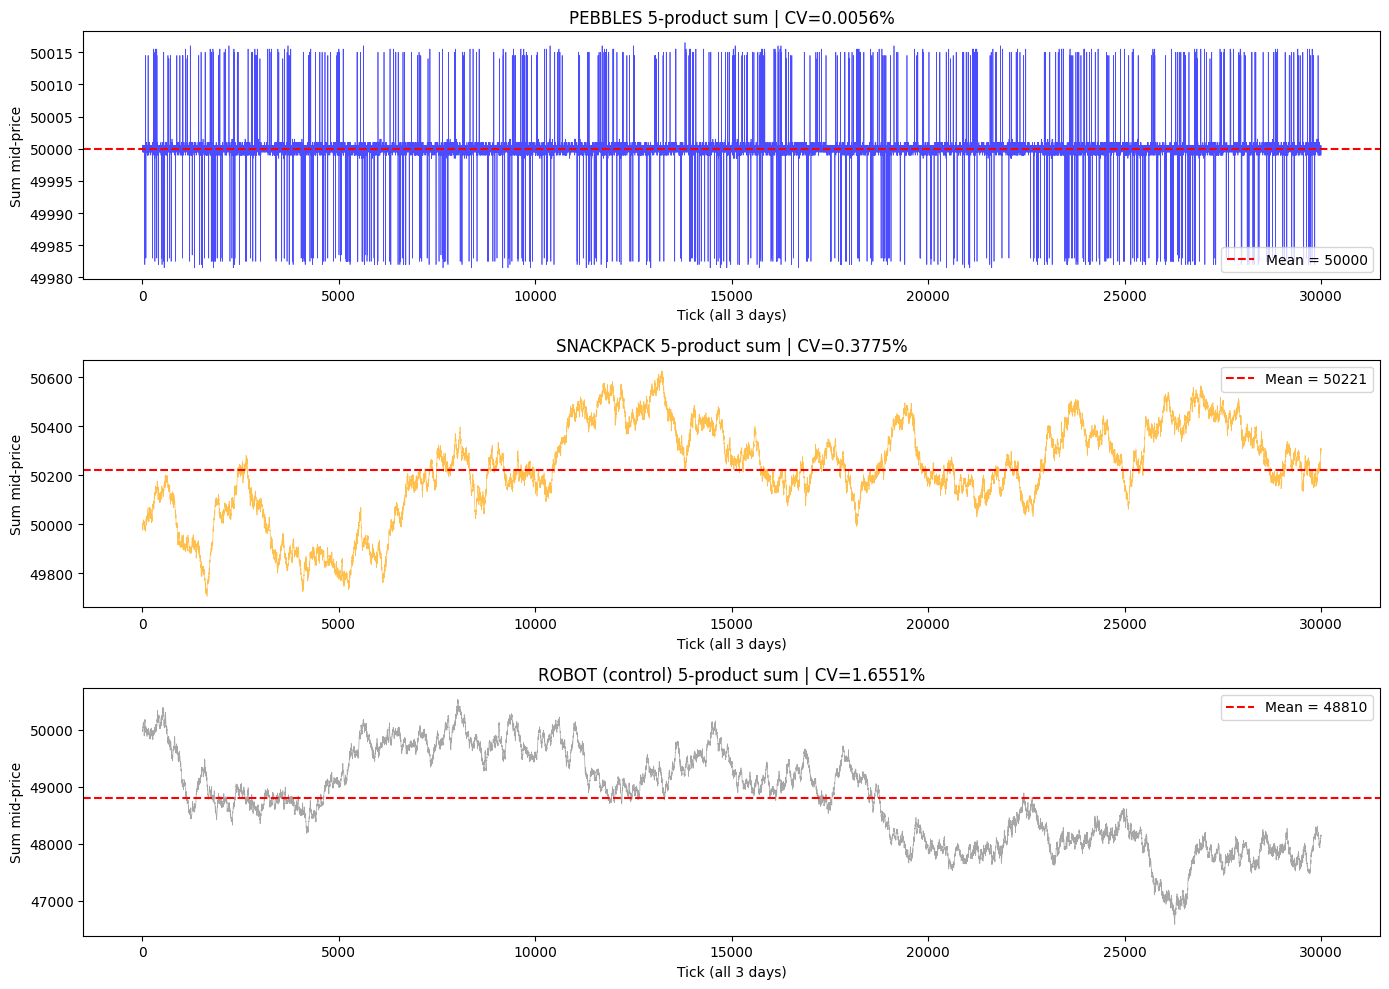

Saved: plots/09_category_sum_constraint.png


In [7]:
# Visualization: PEBBLES 5-sum vs SNACKPACK 5-sum vs ROBOT 5-sum
PLOTS = '/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots'
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (cat, prods, color) in zip(axes, [
    ('PEBBLES', ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL'], 'blue'),
    ('SNACKPACK', ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY'], 'orange'),
    ('ROBOT (control)', ['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_DISHES','ROBOT_LAUNDRY','ROBOT_IRONING'], 'gray'),
]):
    s = pivot_all[prods].sum(axis=1).reset_index(drop=True)
    cv = s.std() / s.mean() * 100
    ax.plot(s.values, color=color, alpha=0.7, linewidth=0.5)
    ax.axhline(s.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {s.mean():.0f}')
    ax.set_title(f'{cat} 5-product sum | CV={cv:.4f}%')
    ax.set_xlabel('Tick (all 3 days)')
    ax.set_ylabel('Sum mid-price')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS}/09_category_sum_constraint.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: plots/09_category_sum_constraint.png')

## 3. Periodic Step Pattern Detection

Scanning for discrete grid behavior (prices confined to multiples of 10), high zero-return frequency (step function signature), and dominant return step sizes.

In [8]:
print('=== Zero-return frequency and grid discreteness (all 50 products) ===')
step_results = []
for prod in products:
    sub = all_df[all_df['product'] == prod].sort_values(['day', 'timestamp'])
    prices = sub['mid_price'].values
    rets = np.diff(prices)
    zero_pct = (rets == 0).mean() * 100
    on_10_grid = (prices % 10 == 0).mean() * 100
    n_unique = len(np.unique(prices))
    # Dominant step size among non-zero returns
    nonzero = rets[rets != 0]
    if len(nonzero) > 0:
        top_step = pd.Series(np.abs(nonzero)).value_counts().index[0]
        top_step_pct = (np.abs(nonzero) == top_step).mean() * 100
    else:
        top_step, top_step_pct = np.nan, np.nan
    step_results.append({
        'product': prod,
        'zero_ret_pct': zero_pct,
        'on_10_grid_pct': on_10_grid,
        'n_unique_prices': n_unique,
        'dominant_step': top_step,
        'dominant_step_pct': top_step_pct,
    })

step_df = pd.DataFrame(step_results).sort_values('zero_ret_pct', ascending=False)
print('Top 10 by zero-return frequency:')
print(step_df.head(10).to_string(index=False))

=== Zero-return frequency and grid discreteness (all 50 products) ===


Top 10 by zero-return frequency:
                    product  zero_ret_pct  on_10_grid_pct  n_unique_prices  dominant_step  dominant_step_pct
              ROBOT_IRONING     40.391346       96.676667              631           10.0          73.123812
OXYGEN_SHAKE_EVENING_BREATH     39.184639       96.676667              453           10.0          71.102828
               ROBOT_DISHES     27.370912       31.953333             3048            2.0           7.228750
     OXYGEN_SHAKE_CHOCOLATE     15.863862       38.470000             3512           10.0          20.202060
        SNACKPACK_PISTACHIO      5.156839        7.423333             1928            1.0          10.575706
        SNACKPACK_CHOCOLATE      4.160139        3.403333             1900            1.0           8.392752
          SNACKPACK_VANILLA      3.986800        2.676667             1673            1.0           8.474812
             UV_VISOR_AMBER      3.290110        4.826667             5517            1.0      

In [9]:
# Deep dive: ROBOT_IRONING and OXYGEN_SHAKE_EVENING_BREATH
for prod in ['ROBOT_IRONING', 'OXYGEN_SHAKE_EVENING_BREATH']:
    sub = all_df[all_df['product'] == prod].sort_values(['day', 'timestamp'])
    prices = sub['mid_price'].values
    rets = np.diff(prices)
    nonzero = rets[rets != 0]
    
    print(f'{prod}:')
    print(f'  Unique prices: {len(np.unique(prices))}')
    print(f'  Zero returns: {(rets==0).mean()*100:.1f}%')
    print(f'  On 10-grid:   {(prices % 10 == 0).mean()*100:.1f}%')
    print(f'  |ret|==10:    {(np.abs(nonzero)==10).mean()*100:.1f}%')
    print(f'  |ret|==20:    {(np.abs(nonzero)==20).mean()*100:.1f}%')
    print(f'  Top return values:')
    print(pd.Series(rets).value_counts().head(6).to_string())
    print()

ROBOT_IRONING:
  Unique prices: 631
  Zero returns: 40.4%
  On 10-grid:   96.7%
  |ret|==10:    73.1%
  |ret|==20:    14.6%
  Top return values:
 0.0     12117
-10.0     6561
 10.0     6515
-20.0     1338
 20.0     1265
-1.5       335

OXYGEN_SHAKE_EVENING_BREATH:
  Unique prices: 453
  Zero returns: 39.2%
  On 10-grid:   96.7%
  |ret|==10:    71.1%
  |ret|==20:    16.3%
  Top return values:
 0.0     11755
-10.0     6498
 10.0     6474
-20.0     1502
 20.0     1479
-3.0       386



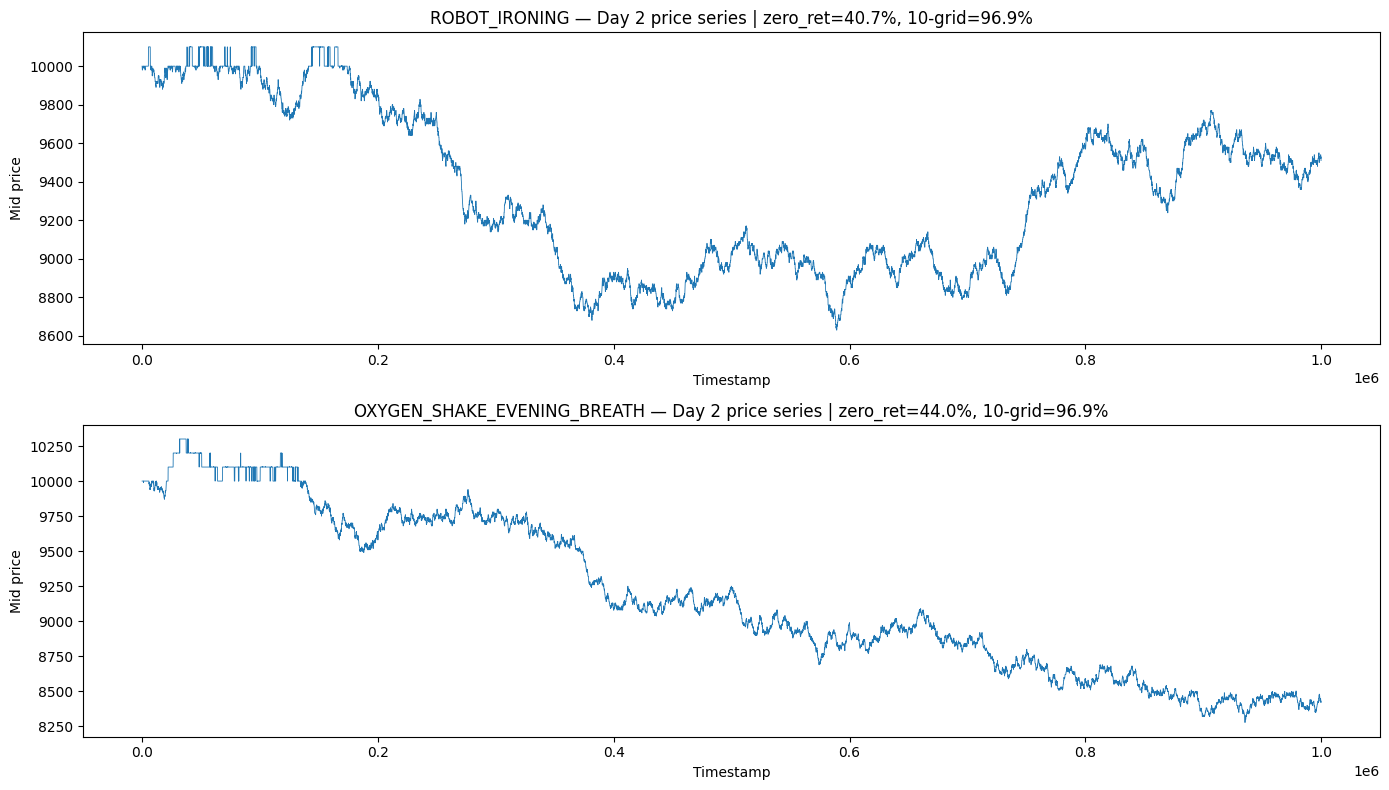

Saved: plots/09_step_function_products.png


In [10]:
# Visualize ROBOT_IRONING and OXYGEN_SHAKE_EVENING_BREATH price series (step function evidence)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, prod in zip(axes, ['ROBOT_IRONING', 'OXYGEN_SHAKE_EVENING_BREATH']):
    sub = all_df[(all_df['product'] == prod) & (all_df['day'] == 2)].sort_values('timestamp')
    ax.plot(sub['timestamp'].values, sub['mid_price'].values, linewidth=0.6)
    zero_pct = (np.diff(sub['mid_price'].values) == 0).mean() * 100
    ax.set_title(f'{prod} — Day 2 price series | zero_ret={zero_pct:.1f}%, 10-grid={(sub["mid_price"].values % 10 == 0).mean()*100:.1f}%')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid price')

plt.tight_layout()
plt.savefig(f'{PLOTS}/09_step_function_products.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: plots/09_step_function_products.png')

## 4. Outlier Ticks > 5σ (per-day basis)

Computing z-scores of tick-to-tick returns within each day to avoid cross-day regime contamination.

In [11]:
print('=== Per-day outlier detection (|z| > 5 on tick returns) ===')
outlier_results = {}
for prod in products:
    total_out = 0
    for d in [2, 3, 4]:
        sub = all_df[(all_df['product'] == prod) & (all_df['day'] == d)].sort_values('timestamp')
        prices = sub['mid_price'].values
        rets = np.diff(prices)
        if rets.std() == 0:
            continue
        z = np.abs((rets - rets.mean()) / rets.std())
        total_out += (z > 5).sum()
    outlier_results[prod] = total_out

outlier_df = pd.Series(outlier_results).sort_values(ascending=False)
print('Products with > 0 outlier ticks (per-day 5σ threshold):')
print(outlier_df[outlier_df > 0])
print(f'\nProducts with zero outlier ticks: {(outlier_df == 0).sum()}/50')

=== Per-day outlier detection (|z| > 5 on tick returns) ===


Products with > 0 outlier ticks (per-day 5σ threshold):
OXYGEN_SHAKE_CHOCOLATE         71
OXYGEN_SHAKE_EVENING_BREATH    66
ROBOT_IRONING                  56
dtype: int64

Products with zero outlier ticks: 47/50


In [12]:
# Examine outlier context for OXYGEN_SHAKE_CHOCOLATE
prod = 'OXYGEN_SHAKE_CHOCOLATE'
sub = all_df[all_df['product'] == prod].sort_values(['day', 'timestamp'])
prices = sub['mid_price'].values
rets = np.diff(prices)

print(f'OXYGEN_SHAKE_CHOCOLATE outlier return values:')
for d in [2, 3, 4]:
    sub_d = all_df[(all_df['product'] == prod) & (all_df['day'] == d)].sort_values('timestamp')
    p = sub_d['mid_price'].values
    r = np.diff(p)
    mu, sig = r.mean(), r.std()
    if sig == 0:
        continue
    z = np.abs((r - mu) / sig)
    outlier_r = r[z > 5]
    print(f'  Day {d}: {len(outlier_r)} outliers, values: {sorted(np.unique(outlier_r))}')

print()
# Check if outliers are rapid ±100 oscillations  
all_outlier_rets = []
for d in [2, 3, 4]:
    sub_d = all_df[(all_df['product'] == prod) & (all_df['day'] == d)].sort_values('timestamp')
    p = sub_d['mid_price'].values
    r = np.diff(p)
    mu, sig = r.mean(), r.std()
    if sig == 0:
        continue
    z = np.abs((r - mu) / sig)
    all_outlier_rets.extend(r[z > 5].tolist())

print(f'All outlier return magnitudes: min={min(np.abs(all_outlier_rets)):.1f}, max={max(np.abs(all_outlier_rets)):.1f}')
print(f'Returns near ±100: {sum(1 for r in all_outlier_rets if abs(abs(r) - 100) <= 5)}/{len(all_outlier_rets)}')

OXYGEN_SHAKE_CHOCOLATE outlier return values:
  Day 2: 14 outliers, values: [np.float64(-100.0), np.float64(100.0), np.float64(103.5)]
  Day 3: 0 outliers, values: []
  Day 4: 57 outliers, values: [np.float64(-100.0), np.float64(96.5), np.float64(100.0)]



All outlier return magnitudes: min=96.5, max=103.5
Returns near ±100: 71/71


## 5. Gap Detection (Missing Timestamps)

Scanning all products × days for non-100-step timestamp gaps.

In [13]:
print('=== Timestamp gap scan (expected step = 100) ===')
gaps_found = {}
for prod in products:
    for d in [2, 3, 4]:
        ts = all_df[(all_df['product'] == prod) & (all_df['day'] == d)]['timestamp'].sort_values().values
        diffs = np.diff(ts)
        bad = diffs[diffs != 100]
        if len(bad) > 0:
            gaps_found[f'{prod}_day{d}'] = bad

if gaps_found:
    print(f'Found {len(gaps_found)} product-day combinations with non-100 gaps:')
    for k, v in gaps_found.items():
        print(f'  {k}: {len(v)} gaps, values={v[:5]}')
else:
    print('RESULT: No gaps found. All 50 products x 3 days have exactly consecutive 100-step timestamps.')
    print('Total: 10,000 ticks per product per day, 0 to 999,900 at step 100.')

=== Timestamp gap scan (expected step = 100) ===


RESULT: No gaps found. All 50 products x 3 days have exactly consecutive 100-step timestamps.
Total: 10,000 ticks per product per day, 0 to 999,900 at step 100.


## 6. Near-Identical Timeseries (Corr > 0.99)

Full 50×50 correlation check on day-2 mid-price levels.

In [14]:
# Pairwise correlation on price levels, day 2
day2_pivot = all_df[all_df['day'] == 2].pivot_table(index='timestamp', columns='product', values='mid_price')
corr_matrix = day2_pivot.corr()

# Find pairs with |corr| > 0.99 (exact copy or mirror)
print('=== Near-identical pairs (|corr| > 0.99, day 2 price levels) ===')
high_corr_pairs = []
for i, p1 in enumerate(products):
    for j, p2 in enumerate(products):
        if j <= i:
            continue
        if p1 in corr_matrix.columns and p2 in corr_matrix.columns:
            c = corr_matrix.loc[p1, p2]
            if abs(c) > 0.99:
                high_corr_pairs.append((p1, p2, c))

if high_corr_pairs:
    for p1, p2, c in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {p1} vs {p2}: corr={c:.4f}')
else:
    print('No pairs with |corr| > 0.99 found on day 2 price levels.')
    # Check 0.95 threshold too
    pairs_95 = sum(1 for i, p1 in enumerate(products) for j, p2 in enumerate(products)
                  if j > i and p1 in corr_matrix.columns and p2 in corr_matrix.columns
                  and abs(corr_matrix.loc[p1, p2]) > 0.95)
    print(f'Pairs with |corr| > 0.95: {pairs_95}')

# Also check within SNACKPACK (CHOC vs VAN had corr -0.974)
print()
print('=== Within-category high negative correlations (|corr| > 0.9) ===')
for cat, prods in categories.items():
    sub_corr = corr_matrix.loc[prods, prods]
    upper = sub_corr.where(np.triu(np.ones(sub_corr.shape), k=1).astype(bool))
    high_neg = [(p1, p2, upper.loc[p1, p2]) for p1 in prods for p2 in prods
                if p1 < p2 and upper.loc[p1, p2] < -0.9]
    if high_neg:
        for p1, p2, c in high_neg:
            print(f'  {cat}: {p1} vs {p2}: corr={c:.4f}')

=== Near-identical pairs (|corr| > 0.99, day 2 price levels) ===
No pairs with |corr| > 0.99 found on day 2 price levels.
Pairs with |corr| > 0.95: 1

=== Within-category high negative correlations (|corr| > 0.9) ===
  SNACKPACK: SNACKPACK_CHOCOLATE vs SNACKPACK_VANILLA: corr=-0.9737


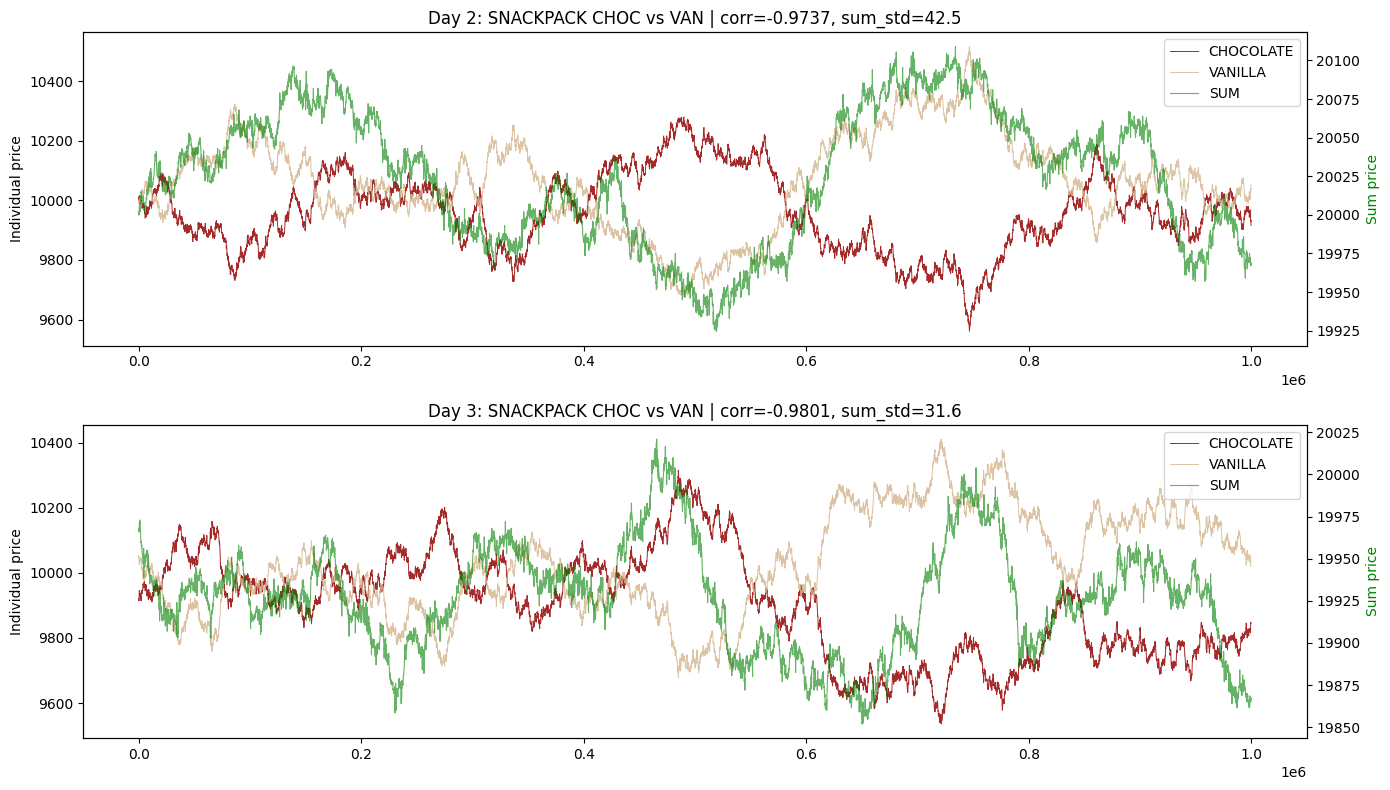

Saved: plots/09_snackpack_mirror_pair.png


In [15]:
# Visualize SNACKPACK_CHOCOLATE vs SNACKPACK_VANILLA (mirror pair)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for d, ax in zip([2, 3], axes):
    sub = all_df[all_df['day'] == d].pivot_table(index='timestamp', columns='product', values='mid_price')
    ts = sub.index.values
    choc = sub['SNACKPACK_CHOCOLATE'].values
    van = sub['SNACKPACK_VANILLA'].values
    c = np.corrcoef(choc, van)[0, 1]
    pair_sum = choc + van
    ax2 = ax.twinx()
    ax.plot(ts, choc, label='CHOCOLATE', color='brown', linewidth=0.7)
    ax.plot(ts, van, label='VANILLA', color='tan', linewidth=0.7, alpha=0.8)
    ax2.plot(ts, pair_sum, label='SUM', color='green', linewidth=0.8, alpha=0.6)
    ax.set_title(f'Day {d}: SNACKPACK CHOC vs VAN | corr={c:.4f}, sum_std={pair_sum.std():.1f}')
    ax.set_ylabel('Individual price')
    ax2.set_ylabel('Sum price', color='green')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(f'{PLOTS}/09_snackpack_mirror_pair.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: plots/09_snackpack_mirror_pair.png')

## 7. FFT Periodicity vs Shuffled-Return Null Distribution

For each product, compare the max FFT amplitude (detrended, excluding 3 lowest frequency bins) against the 99th percentile of the same metric computed on 50 shuffled-return surrogates. This calibrates the noise floor for 'periodicity detection.'

In [16]:
def fft_snr(prices):
    """FFT signal-to-noise ratio: max amplitude / median amplitude, excluding 3 lowest freq bins."""
    p_dt = prices - np.linspace(prices[0], prices[-1], len(prices))
    fft = np.abs(np.fft.rfft(p_dt))
    fft_trim = fft[3:]
    if np.median(fft_trim) == 0:
        return np.nan
    return fft_trim.max() / np.median(fft_trim)

np.random.seed(42)
print('=== FFT SNR: real vs shuffled-returns null (day 2, 50 shuffle iterations) ===')
fft_results = []

for prod in products:
    sub = all_df[(all_df['product'] == prod) & (all_df['day'] == 2)].sort_values('timestamp')
    prices = sub['mid_price'].values
    real_snr = fft_snr(prices)
    
    rets = np.diff(prices)
    shuffle_snrs = []
    for _ in range(50):
        r = rets.copy()
        np.random.shuffle(r)
        shuffled = np.concatenate([[prices[0]], prices[0] + np.cumsum(r)])
        shuffle_snrs.append(fft_snr(shuffled))
    
    null_p99 = np.percentile(shuffle_snrs, 99)
    fft_results.append({
        'product': prod,
        'real_snr': real_snr,
        'null_p99': null_p99,
        'significant': real_snr > null_p99,
        'ratio': real_snr / null_p99 if null_p99 > 0 else np.nan,
    })

fft_df = pd.DataFrame(fft_results).sort_values('ratio', ascending=False)
sig_count = fft_df['significant'].sum()
print(f'Products with significant FFT periodicity (vs shuffled null): {sig_count}/50')
print()
print('Top 10 by ratio (real_snr / null_p99):')
print(fft_df.head(10).to_string(index=False))

=== FFT SNR: real vs shuffled-returns null (day 2, 50 shuffle iterations) ===


Products with significant FFT periodicity (vs shuffled null): 1/50

Top 10 by ratio (real_snr / null_p99):
                  product    real_snr    null_p99  significant    ratio
                PANEL_1X2 1515.487824 1498.628004         True 1.011250
        SNACKPACK_VANILLA 1383.587553 1556.791269        False 0.888743
         MICROCHIP_CIRCLE 1424.951131 1639.423793        False 0.869178
      SLEEP_POD_POLYESTER 1284.227071 1596.243772        False 0.804531
GALAXY_SOUNDS_SOLAR_WINDS 1159.379396 1490.245285        False 0.777979
      SNACKPACK_CHOCOLATE 1278.283236 1748.412326        False 0.731111
                PANEL_1X4 1096.361252 1519.696291        False 0.721434
     SNACKPACK_STRAWBERRY 1094.313163 1559.424087        False 0.701742
GALAXY_SOUNDS_BLACK_HOLES 1149.603735 1744.162241        False 0.659115
          UV_VISOR_ORANGE  968.121009 1482.013579        False 0.653247


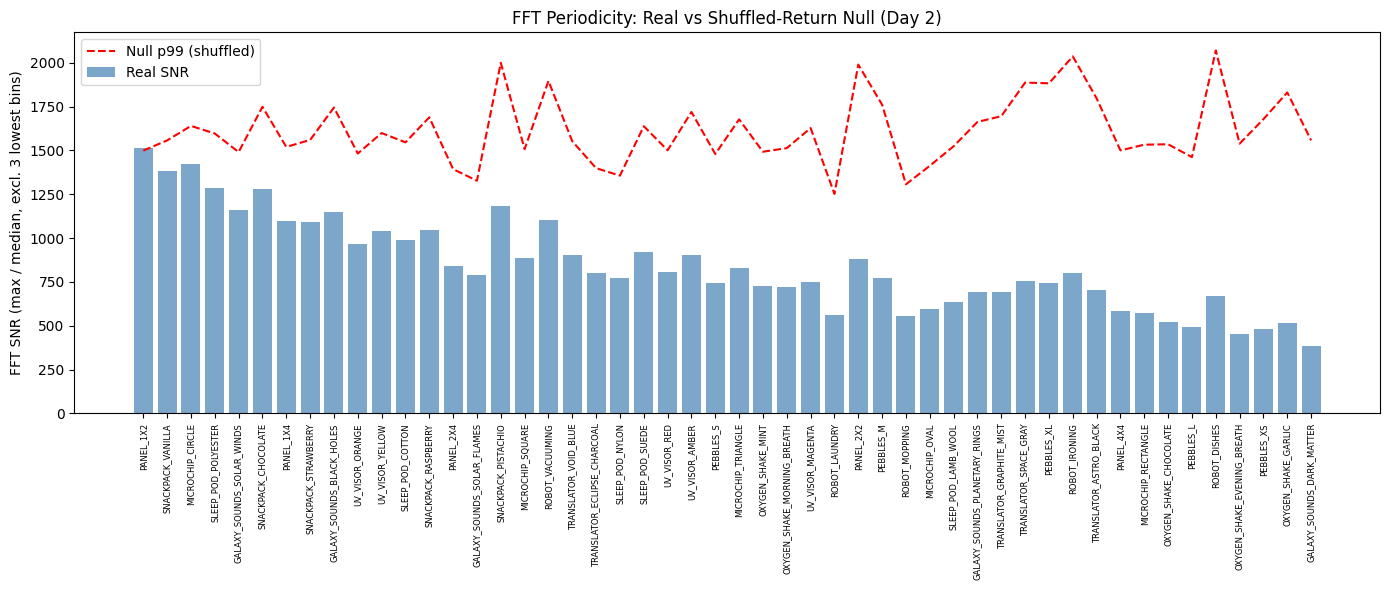

Saved: plots/09_fft_snr_comparison.png


In [17]:
# Visualize the FFT SNR comparison (real vs null p99)
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(fft_df))
ax.bar(x, fft_df['real_snr'].values, alpha=0.7, label='Real SNR', color='steelblue')
ax.plot(x, fft_df['null_p99'].values, 'r--', linewidth=1.5, label='Null p99 (shuffled)')
ax.set_xticks(x)
ax.set_xticklabels(fft_df['product'].values, rotation=90, fontsize=6)
ax.set_ylabel('FFT SNR (max / median, excl. 3 lowest bins)')
ax.set_title('FFT Periodicity: Real vs Shuffled-Return Null (Day 2)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/09_fft_snr_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: plots/09_fft_snr_comparison.png')

## 8. Pebbles & Microchips Focused Analysis

Brief AGENT_BRIEF flagged these two categories as anomalous by trade-count. Testing for embedded patterns.

In [18]:
# Large jump analysis: frequency and regularity of jumps > 3σ
print('=== Large jump analysis (Pebbles & Microchips) ===')
for cat, prods in [('Pebbles', categories['PEBBLES']), ('Microchips', categories['MICROCHIP'])]:
    print(f'\n--- {cat} ---')
    for prod in prods:
        sub = all_df[all_df['product'] == prod].sort_values(['day', 'timestamp'])
        prices = sub['mid_price'].values
        rets = np.diff(prices)
        thr = 3 * rets.std()
        jump_idx = np.where(np.abs(rets) > thr)[0]
        if len(jump_idx) > 1:
            gaps = np.diff(jump_idx)
            print(f'  {prod}: {len(jump_idx)} large jumps | gap mean={gaps.mean():.1f} std={gaps.std():.1f}')
        else:
            print(f'  {prod}: {len(jump_idx)} large jumps')

=== Large jump analysis (Pebbles & Microchips) ===

--- Pebbles ---
  PEBBLES_XS: 69 large jumps | gap mean=427.8 std=411.8
  PEBBLES_S: 69 large jumps | gap mean=431.5 std=383.2
  PEBBLES_M: 77 large jumps | gap mean=383.6 std=256.4
  PEBBLES_L: 74 large jumps | gap mean=397.2 std=445.7


  PEBBLES_XL: 72 large jumps | gap mean=406.5 std=424.5

--- Microchips ---


  MICROCHIP_CIRCLE: 96 large jumps | gap mean=314.3 std=453.4
  MICROCHIP_OVAL: 152 large jumps | gap mean=176.7 std=415.2
  MICROCHIP_SQUARE: 113 large jumps | gap mean=238.2 std=469.4
  MICROCHIP_RECTANGLE: 96 large jumps | gap mean=304.8 std=459.7
  MICROCHIP_TRIANGLE: 100 large jumps | gap mean=298.6 std=405.0


In [19]:
# Check Pebbles individual product volatility and whether they share a mean-reversion signal
# Pebbles constraint: sum = 50000 always, so any deviation is mean-reverting
print('=== Pebbles individual product statistics ===')
prods_pebbles = categories['PEBBLES']
for prod in prods_pebbles:
    sub = all_df[all_df['product'] == prod]['mid_price']
    print(f'  {prod}: mean={sub.mean():.0f}, std={sub.std():.0f}, range=[{sub.min():.0f},{sub.max():.0f}]')

print()
print('Note: Individual Pebbles have wide ranges (each deviates freely),')
print('but the 5-product SUM is constrained to 50000 (CV=0.006%).')
print('This means each product\'s deviation from its mean is offset by the others.')

=== Pebbles individual product statistics ===


  PEBBLES_XS: mean=7405, std=1450, range=[5052,10496]


  PEBBLES_S: mean=8932, std=833, range=[6784,10687]
  PEBBLES_M: mean=10263, std=688, range=[8388,11505]
  PEBBLES_L: mean=10174, std=622, range=[8632,11734]
  PEBBLES_XL: mean=13226, std=1777, range=[9188,17240]

Note: Individual Pebbles have wide ranges (each deviates freely),
but the 5-product SUM is constrained to 50000 (CV=0.006%).
This means each product's deviation from its mean is offset by the others.


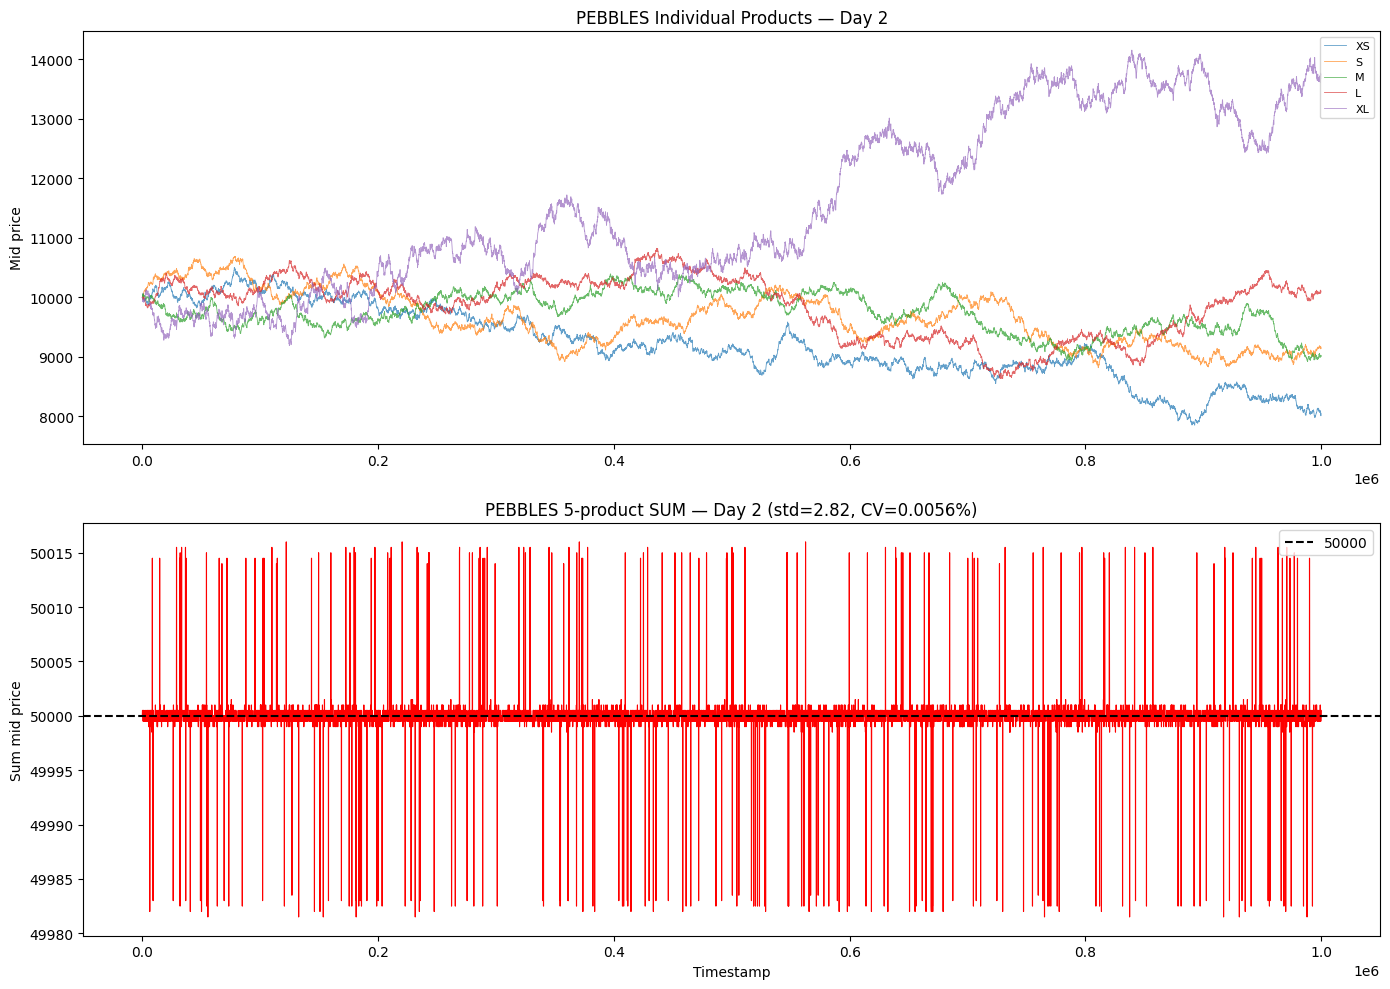

Saved: plots/09_pebbles_sum_constraint.png


In [20]:
# Visualize all 5 Pebbles with sum overlay
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Day 2 individual series
sub = all_df[all_df['day'] == 2].pivot_table(index='timestamp', columns='product', values='mid_price')
ts = sub.index.values
for prod in categories['PEBBLES']:
    ax1.plot(ts, sub[prod].values, alpha=0.7, linewidth=0.6, label=prod.split('_')[-1])
ax1.set_title('PEBBLES Individual Products — Day 2')
ax1.set_ylabel('Mid price')
ax1.legend(loc='upper right', fontsize=8)

# Sum
psum = sub[categories['PEBBLES']].sum(axis=1).values
ax2.plot(ts, psum, color='red', linewidth=0.8)
ax2.axhline(50000, color='black', linestyle='--', linewidth=1.5, label='50000')
ax2.set_title(f'PEBBLES 5-product SUM — Day 2 (std={psum.std():.2f}, CV={psum.std()/psum.mean()*100:.4f}%)')
ax2.set_ylabel('Sum mid price')
ax2.set_xlabel('Timestamp')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS}/09_pebbles_sum_constraint.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: plots/09_pebbles_sum_constraint.png')

## 9. Synthetic GBM Control — Noise Floor Calibration

In [21]:
# Generate 100 GBM paths and compute zero-return % and mode prevalence as baselines
np.random.seed(42)
n = 10000

gbm_zero_rets = []
gbm_mode_pcts = []
gbm_unique_prices = []

for _ in range(200):
    log_ret = np.random.normal(0, 0.001, n)
    p = 10000 * np.cumprod(np.exp(log_ret))
    # Discretize to 0.5 steps (as in real data)
    p = np.round(p * 2) / 2
    rets = np.diff(p)
    gbm_zero_rets.append((rets == 0).mean() * 100)
    mode_pct = pd.Series(p).value_counts().iloc[0] / len(p) * 100
    gbm_mode_pcts.append(mode_pct)
    gbm_unique_prices.append(pd.Series(p).nunique())

print('=== GBM (discretized) baseline statistics ===')
print(f'Zero return %: mean={np.mean(gbm_zero_rets):.2f}%, p99={np.percentile(gbm_zero_rets, 99):.2f}%')
print(f'Mode prevalence: mean={np.mean(gbm_mode_pcts):.2f}%, p99={np.percentile(gbm_mode_pcts, 99):.2f}%')
print(f'Unique prices: mean={np.mean(gbm_unique_prices):.0f}, p1={np.percentile(gbm_unique_prices, 1):.0f}')
print()
print('=== Comparison to anomalous products ===')
anomalies = [
    ('ROBOT_IRONING', 40.4, 0.18, 631),
    ('OXYGEN_SHAKE_EVENING_BREATH', 39.2, 0.12, 453),
    ('ROBOT_DISHES', 27.4, 5.38, 3048),
]
print(f'{"Product":<35} {"zero_ret%":>10} {"GBM_p99":>10} {"significant":>12}')
for prod, zero_pct, mode_pct, uniq in anomalies:
    sig = 'YES' if zero_pct > np.percentile(gbm_zero_rets, 99) else 'no'
    print(f'{prod:<35} {zero_pct:>10.1f} {np.percentile(gbm_zero_rets, 99):>10.2f} {sig:>12}')

=== GBM (discretized) baseline statistics ===
Zero return %: mean=2.00%, p99=2.40%
Mode prevalence: mean=0.18%, p99=0.25%
Unique prices: mean=2542, p1=1540

=== Comparison to anomalous products ===
Product                              zero_ret%    GBM_p99  significant
ROBOT_IRONING                             40.4       2.40          YES
OXYGEN_SHAKE_EVENING_BREATH               39.2       2.40          YES
ROBOT_DISHES                              27.4       2.40          YES


## 10. Summary Table — Anomaly Scores per Product

Aggregating all lenses into a single summary.

In [22]:
# Build summary table
summary_rows = []
for prod in products:
    sub = all_df[all_df['product'] == prod]
    prices = sub.sort_values(['day','timestamp'])['mid_price'].values
    rets = np.diff(prices)
    
    # Determine category
    cat = next((k for k, v in categories.items() if prod in v), 'UNKNOWN')
    
    # Mode prevalence
    mode_pct = (prices == pd.Series(prices).mode()[0]).mean() * 100
    
    # Zero return pct
    zero_pct = (rets == 0).mean() * 100
    
    # On 10-grid
    on_grid = (prices % 10 == 0).mean() * 100
    
    # Per-day outliers
    n_outliers = outlier_results.get(prod, 0)
    
    # Category sum CV
    cat_cv = sum_df[sum_df['category'] == cat]['cv_pct'].values[0] if cat in sum_df['category'].values else np.nan
    
    # FFT significance
    fft_sig = fft_df[fft_df['product'] == prod]['significant'].values[0]
    
    # Triage call based on lenses
    if cat == 'PEBBLES':
        triage = 'likely exploitable'
    elif zero_pct > 35:
        triage = 'likely exploitable'
    elif zero_pct > 10 or cat == 'SNACKPACK':
        triage = 'probably tradable'
    elif n_outliers > 50:
        triage = 'probably tradable'
    else:
        triage = 'probably noise'
    
    summary_rows.append({
        'product': prod,
        'category': cat,
        'mode_pct': round(mode_pct, 2),
        'zero_ret_pct': round(zero_pct, 1),
        'on_10_grid_pct': round(on_grid, 1),
        'n_outlier_ticks': n_outliers,
        'cat_sum_cv_pct': round(cat_cv, 4),
        'fft_significant': fft_sig,
        'triage_09': triage,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['triage_09', 'category', 'product'])
print('=== Notebook 09 Summary Table ===')
print(summary_df.to_string(index=False))

=== Notebook 09 Summary Table ===
                      product     category  mode_pct  zero_ret_pct  on_10_grid_pct  n_outlier_ticks  cat_sum_cv_pct  fft_significant          triage_09
  OXYGEN_SHAKE_EVENING_BREATH OXYGEN_SHAKE      2.27          39.2            96.7               66          2.1408            False likely exploitable
                    PEBBLES_L      PEBBLES      0.12           1.8             4.9                0          0.0056            False likely exploitable
                    PEBBLES_M      PEBBLES      0.09           1.7             5.4                0          0.0056            False likely exploitable
                    PEBBLES_S      PEBBLES      0.12           1.9             5.8                0          0.0056            False likely exploitable
                   PEBBLES_XL      PEBBLES      0.06           0.8             5.3                0          0.0056            False likely exploitable
                   PEBBLES_XS      PEBBLES      0.09  

In [23]:
# Final summary by category
print('=== Key findings by category ===')
cat_groups = summary_df.groupby('category').agg(
    mean_zero_ret_pct=('zero_ret_pct', 'mean'),
    mean_on_grid_pct=('on_10_grid_pct', 'mean'),
    total_outlier_ticks=('n_outlier_ticks', 'sum'),
    cat_sum_cv_pct=('cat_sum_cv_pct', 'first'),
    fft_sig_count=('fft_significant', 'sum'),
).sort_values('cat_sum_cv_pct')
print(cat_groups.to_string())

=== Key findings by category ===
              mean_zero_ret_pct  mean_on_grid_pct  total_outlier_ticks  cat_sum_cv_pct  fft_sig_count
category                                                                                             
PEBBLES                    1.60              5.26                    0          0.0056              0
SNACKPACK                  3.98              4.26                    0          0.3775              0
UV_VISOR                   2.66              4.60                    0          1.4422              0
TRANSLATOR                 2.74              4.30                    0          1.6474              0
ROBOT                     15.00             28.38                   56          1.6551              0
PANEL                      2.72              4.68                    0          1.7340              1
OXYGEN_SHAKE              12.50             29.60                  137          2.1408              0
MICROCHIP                  2.14              5.04